Ten notebook jest przeznaczony do badania algorytmów na zbiorach tekstowych **BBC News**

# BBC News Embeddings

Ten zbiór danych składa się z 2225 dokumentów ze strony BBC news odnoszących się do 5 obszrów tematycznych z lat 2004-2005


1.  **Wektoryzacja tesktów** tworzymy reprezentacje wektorowe na dwa sposoby, źeby pokazać,
 źe na późniejszą redukcję wymiarów duźy wpływ ma tekźe awybór algorytmu, który tworzt wektory

- paragraph-embedddingi MiniLM https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

- TF-IDF

2.

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from utils.scores import Dataset

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Załadowanie danych

In [3]:
bbc_data = pd.read_csv('/Users/wiktor/dim_red/Dimensionality-reduction-project/data/bbc-news-data.csv', sep='\t')
bbc_data.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [4]:

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13211.82it/s]


In [5]:
embeddings = []
for category, content in bbc_data[['category', 'content']].values:
    embedding = model.encode(content)
    embeddings.append(embedding)


bbc_data['embedding'] = embeddings
bbc_data.head()


,category,filename,title,content,embedding
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,"[-0.0509832, -0.070668414, 0.013510463, -0.018..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,"[0.0061862837, -0.04703159, -0.017026821, 0.00..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,"[-0.0742608, 0.024880351, -0.014749278, 0.0010..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,"[0.040098097, -0.023337716, -0.010271507, 0.03..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,"[0.026878385, -0.05364739, -0.0075229425, -0.0..."


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(bbc_data['content'])

bbc_data['tdidf_embedding'] = list(tfidf_matrix.toarray())
bbc_data.head()

,category,filename,title,content,embedding,tdidf_embedding
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,"[-0.0509832, -0.070668414, 0.013510463, -0.018...","[0.0, 0.021263676803950603, 0.0, 0.0, 0.0, 0.0..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,"[0.0061862837, -0.04703159, -0.017026821, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,"[-0.0742608, 0.024880351, -0.014749278, 0.0010...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,"[0.040098097, -0.023337716, -0.010271507, 0.03...","[0.0, 0.019997434150077344, 0.0, 0.0, 0.0, 0.0..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,"[0.026878385, -0.05364739, -0.0075229425, -0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# LDA

In [ ]:
import numpy as np
from utils.lda import my_lda
import pandas as pd
import sys
sys.modules['utils.lda'].pd = pd
lda = my_lda(n_components=2)

X_text = np.array(bbc_data['embedding'].tolist())
y_text = bbc_data['category'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_text, y_text, test_size=0.2, random_state=42)
X_train_lda, _ = lda.fit(X_train, y_train)

X_test_lda = np.dot(X_test, model_text_lda.lda_components)

In [ ]:
import matplotlib.pyplot as plt
unique_categories = sorted(list(set(y_test)))
mapper = plt.cm.get_cmap('viridis', len(unique_categories))

plt.figure(figsize=(8, 6))

for i, category in enumerate(unique_categories):
    indices = (y_test == category)

    plt.scatter(
        X_test_lda[indices, 0],
        X_test_lda[indices, 1],
        label=category,
        color=mapper(i),
        alpha=0.8,
        s=40
    )

plt.title("LDA na BBC News", fontsize=13, fontweight='bold')
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Kategorie")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.manifold import trustworthiness

trust_lda = trustworthiness(X_test, X_test_lda, n_neighbors=5)
print(f"Trustworthiness dla LDA: {trust_lda:.4f}")

In [ ]:
from sklearn.metrics import normalized_mutual_info_score, silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=len(set(y_test)),
    random_state=1,
    n_init=10
)

clusters = kmeans.fit_predict(X_test_lda)

nmi_pca = normalized_mutual_info_score(
    y_test,
    clusters
)

sil_pca = silhouette_score(
    X_test_lda,
    clusters
)

cal_har = calinski_harabasz_score(
    X_test_lda,
    clusters
)
print(f"NMI dla LDA: {nmi_pca:.4f}")
print(f"Silhouette dla LDA: {sil_pca:.4f}")
print(f"Calinski-Harabasz dla LDA: {cal_har:.4f}")

# PCA

In [ ]:
import numpy as np
from utils.pca import my_pca
import pandas as pd
import sys
sys.modules['utils.pca'].pd = pd
pca = my_pca(n_components=2)

X_text = np.array(bbc_data['embedding'].tolist())
y_text = bbc_data['category'].values

X_pca, df_pca = pca.fit(X_text)

In [ ]:
import matplotlib.pyplot as plt

mapper = plt.cm.get_cmap('viridis', len(set(bbc_data['category'])))

plt.figure(figsize=(8, 6))
for i, category in enumerate(set(bbc_data['category'])):
    indices = bbc_data['category'] == category
    plt.scatter(X_pca[indices, 0], X_pca[indices, 1], label=category, color=mapper(i), alpha=0.7)

plt.title("PCA na BBC News", fontsize=12)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.manifold import trustworthiness

trust_lda = trustworthiness(X_text, X_pca, n_neighbors=5)
print(f"Trustworthiness dla PCA: {trust_lda:.4f}")

In [ ]:
from sklearn.metrics import normalized_mutual_info_score, silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=1,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

nmi_pca = normalized_mutual_info_score(
    y_text,
    clusters
)

sil_pca = silhouette_score(
    X_pca,
    clusters
)

cal_har = calinski_harabasz_score(
    X_pca,
    clusters
)
print(f"NMI dla PCA: {nmi_pca:.4f}")
print(f"Silhouette dla PCA: {sil_pca:.4f}")
print(f"Calinski-Harabasz dla PCA: {cal_har:.4f}")

## Kernel PCA

In [ ]:
import matplotlib.pyplot as plt
mapper = plt.cm.get_cmap('viridis', len(set(bbc_data['category'])))
for i, category in enumerate(set(bbc_data['category'])):
    indices = bbc_data['category'] == category
    plt.scatter(X_pca_2d[indices, 0], X_pca_2d[indices, 1], label=category, color=mapper(i))
plt.legend()

# UMAP i Isomap

In [7]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# etykiety = kategorie artykułów
le = LabelEncoder()
y = le.fit_transform(bbc_data['category'])
class_names = le.classes_

# --- DOMYŚLNIE: embeddingi SentenceTransformer (gęste, 384 wymiary) ---
X = np.vstack(bbc_data['embedding'].values)

# --- ALTERNATYWA: TF-IDF -> trzeba ściąć SVD, bo jest rzadki i ogromny ---
# from sklearn.decomposition import TruncatedSVD
# X_tfidf = np.vstack(bbc_data['tdidf_embedding'].values)
# X = TruncatedSVD(n_components=100, random_state=42).fit_transform(X_tfidf)

print(X.shape, "->", list(class_names))

(2225, 384) -> ['business', 'entertainment', 'politics', 'sport', 'tech']


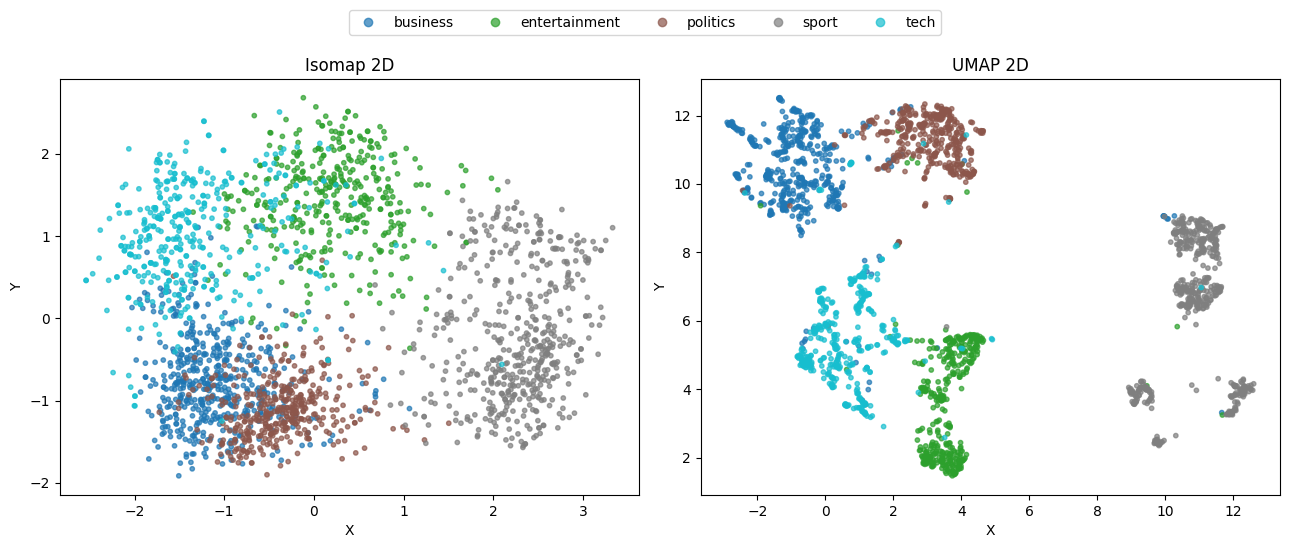

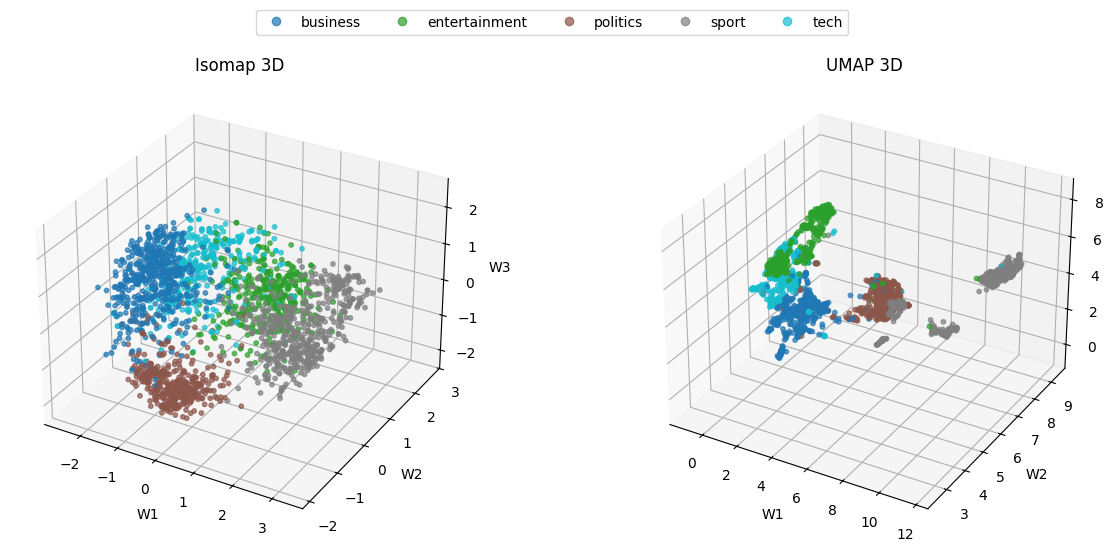

In [16]:
import matplotlib.pyplot as plt
from utils.isomap_umap import isomap, umap_reduce

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

# 2 wymiarowe wizualizacje
emb_iso_2d  = isomap(X, n_components=2, n_neighbors=15, scale=False)
emb_umap_2d = umap_reduce(X, n_components=2, n_neighbors=15, scale=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, emb, title in [(axes[0], emb_iso_2d, "Isomap 2D"), (axes[1], emb_umap_2d, "UMAP 2D")]:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="tab10", s=10, alpha=0.7)
    ax.set_title(title); ax.set_xlabel("X"); ax.set_ylabel("Y")
fig.legend(sc.legend_elements()[0], class_names, loc="upper center",
           ncol=len(class_names), bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

# 3 wymiarowe wizualizacje
emb_iso_3d  = isomap(X, n_components=3, n_neighbors=15, scale=False)
emb_umap_3d = umap_reduce(X, n_components=3, n_neighbors=15, scale=False)

fig = plt.figure(figsize=(13, 5.5))
for i, (emb, title) in enumerate([(emb_iso_3d, "Isomap 3D"), (emb_umap_3d, "UMAP 3D")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    sc = ax.scatter(emb[:, 0], emb[:, 1], emb[:, 2], c=y, cmap="tab10", s=10, alpha=0.7)
    ax.set_title(title); ax.set_xlabel("W1"); ax.set_ylabel("W2"); ax.set_zlabel("W3")
fig.legend(sc.legend_elements()[0], class_names, loc="upper center",
           ncol=len(class_names), bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

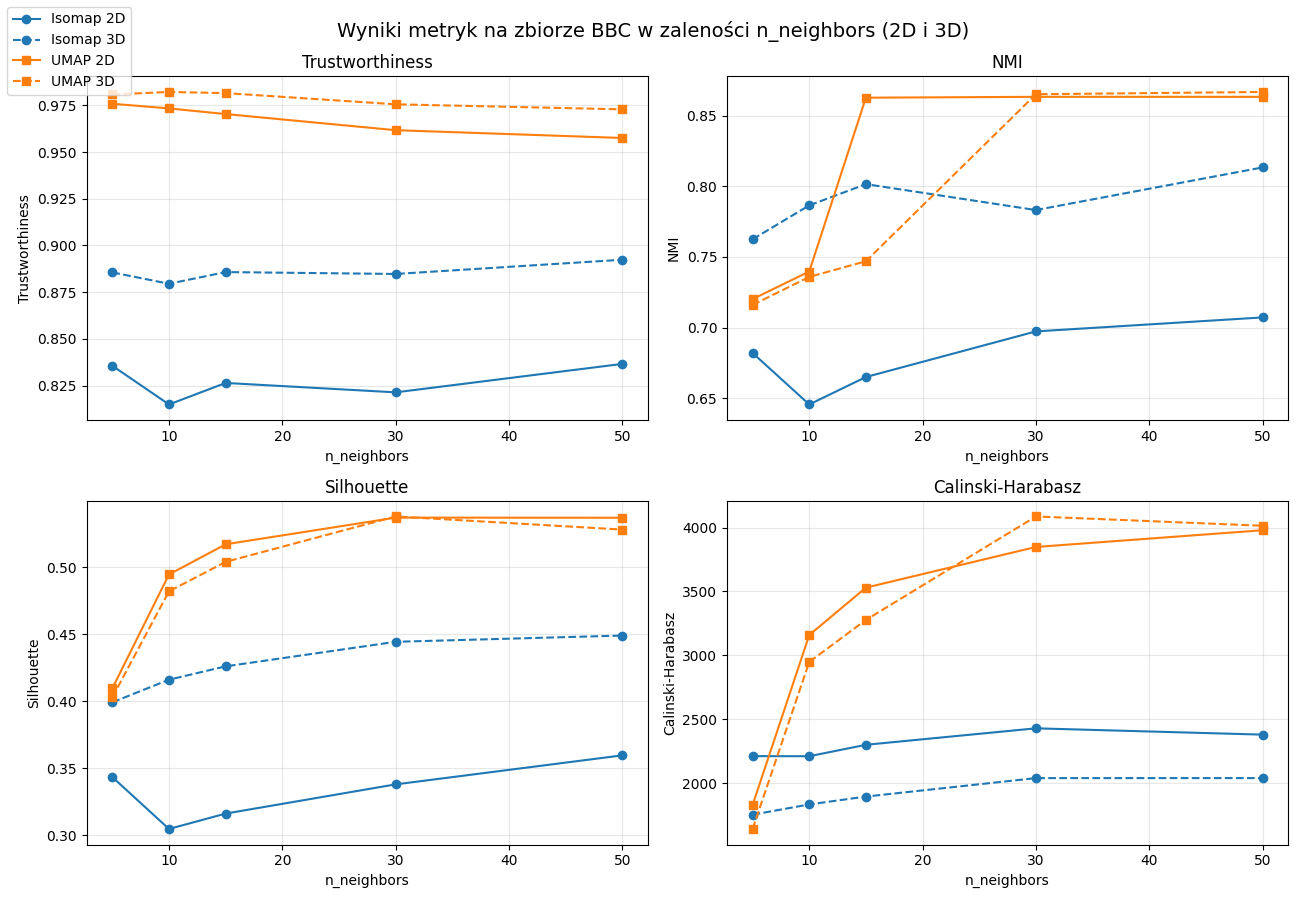

In [ ]:
from sklearn.cluster import KMeans
from sklearn.manifold import trustworthiness
from sklearn.metrics import (
    normalized_mutual_info_score, silhouette_score, calinski_harabasz_score,
)

neighbor_values = [5, 10, 15, 30, 50]
n_clusters = len(class_names)
metric_names = ["Trustworthiness", "NMI", "Silhouette", "Calinski-Harabasz"]

configs = [("isomap", isomap, 2), ("isomap", isomap, 3),
           ("umap", umap_reduce, 2), ("umap", umap_reduce, 3)]
res = {m: {(name, d): [] for name, _, d in configs} for m in metric_names}

for k in neighbor_values:
    for name, fn, d in configs:
        emb = fn(X, n_components=d, n_neighbors=k, scale=False)
        km = KMeans(n_clusters=n_clusters, random_state=1, n_init=10).fit_predict(emb)
        res["Trustworthiness"][(name, d)].append(trustworthiness(X, emb))
        res["NMI"][(name, d)].append(normalized_mutual_info_score(y, km))
        res["Silhouette"][(name, d)].append(silhouette_score(emb, y))
        res["Calinski-Harabasz"][(name, d)].append(calinski_harabasz_score(emb, y))

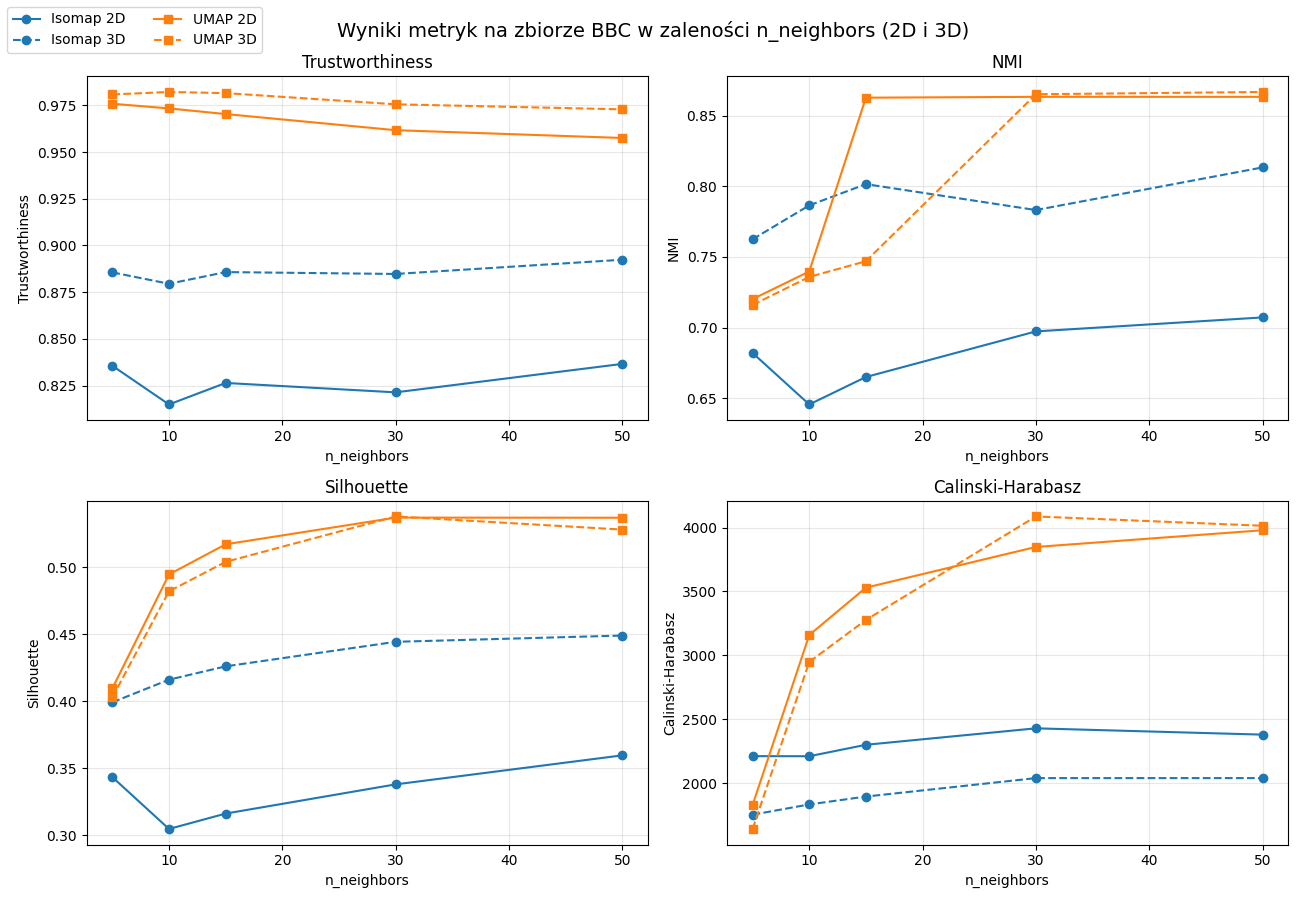

In [14]:
styles = {
    ("isomap", 2): ("o-",  "C0", "Isomap 2D"),
    ("isomap", 3): ("o--", "C0", "Isomap 3D"),
    ("umap", 2):   ("s-",  "C1", "UMAP 2D"),
    ("umap", 3):   ("s--", "C1", "UMAP 3D"),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, metric in zip(axes.ravel(), metric_names):
    for cfg, (fmt, color, label) in styles.items():
        ax.plot(neighbor_values, res[metric][cfg], fmt, color=color, label=label)
    ax.set_title(metric); ax.set_xlabel("n_neighbors"); ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=2)
fig.suptitle("Wyniki metryk na zbiorze BBC w zaleności n_neighbors (2D i 3D)", fontsize=14)
fig.tight_layout(); plt.show()